# GCN vs GraphSAGE on MovieLens-100K

This notebook builds a **graph-based recommender system** on the MovieLens-100K dataset and
compares two Graph Neural Network encoders — **GCN** and **GraphSAGE** — on the task of
**link prediction** (predicting whether a user would interact with / rate a movie).

**Pipeline**
1. Load MovieLens-100K and build a user–item bipartite interaction graph
2. Split edges into train / validation / test sets
3. Define `GCNConv`- and `SAGEConv`-based encoders with a dot-product decoder
4. Train both models with a binary cross-entropy link-prediction loss
5. Evaluate with **ROC-AUC**, **Recall@10**, **Precision@10**
6. Fit a lightweight regression head on top of the learned embeddings and report **RMSE** on held-out ratings
7. Compare GCN vs GraphSAGE side by side


In [3]:
!pip -q install torch-geometric

import torch
import numpy as np
import pandas as pd
from torch_geometric.nn import GCNConv, SAGEConv
print("Setup complete")

Setup complete


## Download MovieLens-100K

In [4]:
import urllib.request, zipfile, os

url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
if not os.path.exists('ml-100k.zip'):
    urllib.request.urlretrieve(url, 'ml-100k.zip')
if not os.path.exists('ml-100k'):
    with zipfile.ZipFile('ml-100k.zip') as z:
        z.extractall()

ratings = pd.read_csv('ml-100k/u.data', sep='\t', header=None,
                       names=['user', 'item', 'rating', 'timestamp'])
print(f"Loaded {len(ratings)} ratings, {ratings.user.nunique()} users, {ratings.item.nunique()} items")
ratings.head()

Loaded 100000 ratings, 943 users, 1682 items


,user,item,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


we change the user nad movie id in a way that they are distinct and so can be used by graph without confusion. we divide our data into train, validate , test and we use only edges from train data .

In [5]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

user_ids = ratings['user'].unique()
item_ids = ratings['item'].unique()
user2idx = {u: i for i, u in enumerate(sorted(user_ids))}
item2idx = {it: i for i, it in enumerate(sorted(item_ids))}

n_users = len(user2idx)
n_items = len(item2idx)
num_nodes = n_users + n_items

ratings['u_node'] = ratings['user'].map(user2idx)
ratings['i_node'] = ratings['item'].map(item2idx) + n_users  # offset items after users

print(f"num_nodes = {num_nodes} (users: {n_users}, items: {n_items})")

num_nodes = 2625 (users: 943, items: 1682)


In [6]:
from sklearn.model_selection import train_test_split

# shuffle & split at the interaction level: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(ratings, test_size=0.2, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")

def edge_index_from_df(df):
    e = torch.tensor(df[['u_node', 'i_node']].values.T, dtype=torch.long)
    e_rev = e.flip(0)
    return torch.cat([e, e_rev], dim=1)  # undirected

# graph structure used for message passing is built ONLY from training interactions
train_edge_index = edge_index_from_df(train_df)
train_pos_edge_label_index = torch.tensor(train_df[['u_node', 'i_node']].values.T, dtype=torch.long)
val_pos_edge_label_index = torch.tensor(val_df[['u_node', 'i_node']].values.T, dtype=torch.long)
test_pos_edge_label_index = torch.tensor(test_df[['u_node', 'i_node']].values.T, dtype=torch.long)

print("train_edge_index:", train_edge_index.shape)

train: 80000  val: 10000  test: 10000
train_edge_index: torch.Size([2, 160000])


## Define the encoders

we use two methods GCN and GraphSage.
GCN takes the weighted average of its neighbour .
Graphsage takes the average of neighbour but concatenates it with its own embedding.
We use two layers of both because then we can get information 2 hops away.
Decoder gets the closeness of user and movie by dot product.  

In [7]:
import torch
import torch.nn.functional as F

EMB_DIM = 64
HIDDEN_DIM = 64
OUT_DIM = 32

class GCNEncoder(torch.nn.Module):
    def __init__(self, num_nodes, emb_dim=EMB_DIM, hidden=HIDDEN_DIM, out_dim=OUT_DIM):
        super().__init__()
        self.emb = torch.nn.Embedding(num_nodes, emb_dim)
        self.conv1 = GCNConv(emb_dim, hidden)
        self.conv2 = GCNConv(hidden, out_dim)
        self.conv3 = GCNConv(out_dim, out_dim)  # Added layer 3
        self.conv4 = GCNConv(out_dim, out_dim)  # Added layer 4

    def forward(self, edge_index):
        x = self.emb.weight
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index).relu() # Added .relu() for intermediate layer
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv3(x, edge_index).relu() # Forward pass through layer 3
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv4(x, edge_index)        # Forward pass through layer 4
        return x


class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, num_nodes, emb_dim=EMB_DIM, hidden=HIDDEN_DIM, out_dim=OUT_DIM):
        super().__init__()
        self.emb = torch.nn.Embedding(num_nodes, emb_dim)
        self.conv1 = SAGEConv(emb_dim, hidden)
        self.conv2 = SAGEConv(hidden, out_dim)
        self.conv3 = SAGEConv(out_dim, out_dim)  # Added layer 3
        self.conv4 = SAGEConv(out_dim, out_dim)  # Added layer 4

    def forward(self, edge_index):
        x = self.emb.weight
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index).relu() # Added .relu() for intermediate layer
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv3(x, edge_index).relu() # Forward pass through layer 3
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv4(x, edge_index)        # Forward pass through layer 4
        return x


def decode(z, edge_label_index):
    src, dst = edge_label_index
    return (z[src] * z[dst]).sum(dim=-1)

print("Encoders defined: GCNEncoder, GraphSAGEEncoder")

Encoders defined: GCNEncoder, GraphSAGEEncoder


## Training

Each model is trained with a standard link-prediction objective: for every batch of positive
(observed) training edges we sample an equal number of random negative edges and minimize binary
cross-entropy between the dot-product logits and the 0/1 edge labels.

In [8]:
from torch_geometric.utils import negative_sampling

def train_model(model_cls, epochs=100, lr=0.01, weight_decay=5e-4, verbose=True):
    torch.manual_seed(SEED)
    model = model_cls(num_nodes)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        z = model(train_edge_index)

        neg_edge_index = negative_sampling(
            edge_index=train_edge_index,
            num_nodes=num_nodes,
            num_neg_samples=train_pos_edge_label_index.size(1),
        )

        edge_label_index = torch.cat([train_pos_edge_label_index, neg_edge_index], dim=1)
        edge_label = torch.cat([
            torch.ones(train_pos_edge_label_index.size(1)),
            torch.zeros(neg_edge_index.size(1)),
        ])

        out = decode(z, edge_label_index)
        loss = F.binary_cross_entropy_with_logits(out, edge_label)
        loss.backward()
        optimizer.step()
        history.append(loss.item())

        if verbose and (epoch % 10 == 0 or epoch == 1):
            val_auc = evaluate_auc(model, val_pos_edge_label_index)
            print(f"epoch {epoch:03d} | train loss {loss.item():.4f} | val AUC {val_auc:.4f}")

    return model, history

## Evaluation utilities

- **ROC-AUC**: can the model separate real held-out interactions from random negative pairs?
- **Recall@10 / Precision@10**: for a sample of users, rank all items the user hasn't interacted
  with in the training graph and check how many of their true held-out "liked" items (rating >= 4)
  land in the top 10.
- **RMSE**: a small linear regression head fit on top of the frozen embeddings' dot product, to
  translate the link score onto the 1-5 rating scale, evaluated on held-out ratings.

In [9]:
from sklearn.metrics import roc_auc_score

def evaluate_auc(model, pos_edge_label_index):
    model.eval()
    with torch.no_grad():
        z = model(train_edge_index)
        neg_edge_index = negative_sampling(
            edge_index=train_edge_index,
            num_nodes=num_nodes,
            num_neg_samples=pos_edge_label_index.size(1),
        )
        edge_label_index = torch.cat([pos_edge_label_index, neg_edge_index], dim=1)
        edge_label = torch.cat([
            torch.ones(pos_edge_label_index.size(1)),
            torch.zeros(neg_edge_index.size(1)),
        ])
        scores = torch.sigmoid(decode(z, edge_label_index))
        return roc_auc_score(edge_label.numpy(), scores.numpy())

In [10]:
def evaluate_ranking(model, k=10, n_eval_users=200, like_threshold=4):
    """Recall@k / Precision@k over a sample of users, ranking all items not seen in training."""
    model.eval()
    with torch.no_grad():
        z = model(train_edge_index)

    train_seen = train_df.groupby('u_node')['i_node'].apply(set).to_dict()
    test_liked = (test_df[test_df.rating >= like_threshold]
                  .groupby('u_node')['i_node'].apply(set).to_dict())

    eval_users = [u for u in test_liked.keys() if len(test_liked[u]) > 0]
    rng = np.random.RandomState(SEED)
    if len(eval_users) > n_eval_users:
        eval_users = list(rng.choice(eval_users, size=n_eval_users, replace=False))

    item_node_ids = torch.arange(n_users, n_users + n_items)
    item_embs = z[item_node_ids]

    recalls, precisions = [], []
    with torch.no_grad():
        for u in eval_users:
            scores = item_embs @ z[u]
            seen = train_seen.get(u, set())
            if seen:
                seen_local = torch.tensor([1.0 if (n_users + idx) in seen else 0.0
                                            for idx in range(n_items)])
                scores = scores - seen_local * 1e9

            topk_idx = torch.topk(scores, k).indices
            topk_items = set((n_users + topk_idx).tolist())

            relevant = test_liked[u]
            hits = len(topk_items & relevant)
            recalls.append(hits / len(relevant))
            precisions.append(hits / k)

    return float(np.mean(recalls)), float(np.mean(precisions))

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def evaluate_rmse(model):
    """Fit a 1D linear map from dot-product score -> rating (1-5) on train edges,
    then report RMSE on held-out test ratings."""
    model.eval()
    with torch.no_grad():
        z = model(train_edge_index)
        train_scores = decode(z, train_pos_edge_label_index).numpy().reshape(-1, 1)
        test_scores = decode(z, test_pos_edge_label_index).numpy().reshape(-1, 1)

    reg = LinearRegression().fit(train_scores, train_df['rating'].values)
    pred = reg.predict(test_scores)
    pred = np.clip(pred, 1, 5)
    rmse = mean_squared_error(test_df['rating'].values, pred) ** 0.5
    return rmse

## Train GCN

In [12]:
print("Training GCN...")
gcn_model, gcn_history = train_model(GCNEncoder, epochs=100)

Training GCN...
epoch 001 | train loss 0.6842 | val AUC 0.8700
epoch 010 | train loss 0.5945 | val AUC 0.8879
epoch 020 | train loss 0.5767 | val AUC 0.8611
epoch 030 | train loss 0.5657 | val AUC 0.8496
epoch 040 | train loss 0.5610 | val AUC 0.8384
epoch 050 | train loss 0.5685 | val AUC 0.8545
epoch 060 | train loss 0.5649 | val AUC 0.8582
epoch 070 | train loss 0.5630 | val AUC 0.8576
epoch 080 | train loss 0.5605 | val AUC 0.8609
epoch 090 | train loss 0.5601 | val AUC 0.8497
epoch 100 | train loss 0.5623 | val AUC 0.8445


## Train GraphSAGE

In [13]:
print("Training GraphSAGE...")
sage_model, sage_history = train_model(GraphSAGEEncoder, epochs=100)

Training GraphSAGE...
epoch 001 | train loss 0.7423 | val AUC 0.5413
epoch 010 | train loss 0.6913 | val AUC 0.6549
epoch 020 | train loss 0.6607 | val AUC 0.7566
epoch 030 | train loss 0.6246 | val AUC 0.7911
epoch 040 | train loss 0.6120 | val AUC 0.8175
epoch 050 | train loss 0.5967 | val AUC 0.8225
epoch 060 | train loss 0.6241 | val AUC 0.8345
epoch 070 | train loss 0.5918 | val AUC 0.8445
epoch 080 | train loss 0.5813 | val AUC 0.8419
epoch 090 | train loss 0.5806 | val AUC 0.8417
epoch 100 | train loss 0.5879 | val AUC 0.8441


## Final evaluation on the test set

In [14]:
results = {}
for name, model in [('GCN', gcn_model), ('GraphSAGE', sage_model)]:
    auc = evaluate_auc(model, test_pos_edge_label_index)
    recall, precision = evaluate_ranking(model, k=10, n_eval_users=200)
    rmse = evaluate_rmse(model)
    results[name] = {'ROC-AUC': auc, 'Recall@10': recall, 'Precision@10': precision, 'RMSE': rmse}

results_df = pd.DataFrame(results).T
results_df

,ROC-AUC,Recall@10,Precision@10,RMSE
GCN,0.841936,0.119023,0.0825,1.101056
GraphSAGE,0.843201,0.089846,0.0765,1.100342


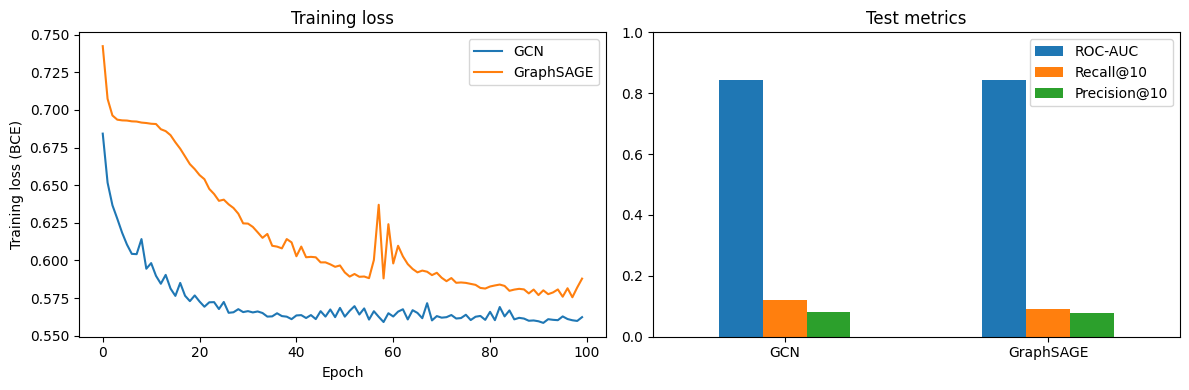

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(gcn_history, label='GCN')
axes[0].plot(sage_history, label='GraphSAGE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss (BCE)')
axes[0].set_title('Training loss')
axes[0].legend()

results_df[['ROC-AUC', 'Recall@10', 'Precision@10']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Test metrics')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Summary

When 2 layers
- from the results GCN is performing better here as it has high ROC , so it has a good approach to unseen pattrens
- The ranking metrics haev a correlation to each other and is claery visible the graph.

when 4 layers
- changinb the number of layers, the ROC is increasing .

also the graphSage method starts performimng bttre than GCN in terms of AUC.
The sudden peak in training loss at 60 epoch might be due to Oversmoothing.

